In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
from IPython.display import display

In [15]:
import seaborn as sns
palette = sns.color_palette("tab10", n_colors=10)
palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

# Synthetic

In [31]:
# df = pd.read_csv('mc_4states_p=0.9_1_27.csv')
df = pd.read_csv('mc_4states_p=0.9_1_30_all.csv')
# df["corrector_step_size"] = 0

# df_fb = pd.read_csv('mc_4states_p=0.9_1_30_fb.csv')
# # concatenate the two dataframes
# df = pd.concat([df, df_fb], axis=0)
df = df.fillna(value="none")
df_full = df
print(df.head())

   seed  nfe forward_process predictor_type    corrector_type  num_steps  \
0     0   16  CosineSchedule            md4  forward_backward          8   
1     1   16  CosineSchedule            md4  forward_backward          8   
2     2   16  CosineSchedule            md4  forward_backward          8   
3     3   16  CosineSchedule            md4  forward_backward          8   
4     4   16  CosineSchedule            md4  forward_backward          8   

  gibbs_k gibbs_temperature  anneal_temperature maskgit_temperature  \
0    none              none               False                none   
1    none              none               False                none   
2    none              none               False                none   
3    none              none               False                none   
4    none              none               False                none   

  corrector_step_size  avg_run_length  error_rate  
0                0.01        5.316939    0.020724  
1           

In [32]:
# Our two metrics are error_rate and avg_run_length
# We want to average metrics over the seed column, remove the seed column, and add the standard deviation columns for avg_run_length and error_rate
df_full

# The columns we want to group by are all columns except for the seed column and the two metrics columns
columns_to_group = [col for col in df_full.columns if col not in ['seed', 'error_rate', 'avg_run_length']]
df_full = df_full.groupby(columns_to_group).agg({'error_rate': ['mean', 'std'], 'avg_run_length': ['mean', 'std']}).reset_index()
df_full.columns = ['_'.join(filter(None, col)) for col in df_full.columns]

In [33]:
df = df_full
df[(df["predictor_type"] == 'md4') & (df["corrector_type"] == 'gibbs')]

,nfe,forward_process,predictor_type,corrector_type,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,corrector_step_size,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std
21,16,CosineSchedule,md4,gibbs,8,1.0,0.01,False,none,none,0.000587,0.000049,7.813837,0.118018
22,16,CosineSchedule,md4,gibbs,8,1.0,0.01,True,none,none,0.016831,0.000446,6.514889,0.109742
23,16,CosineSchedule,md4,gibbs,8,1.0,0.1,False,none,none,0.000591,0.000042,7.778403,0.104355
24,16,CosineSchedule,md4,gibbs,8,1.0,0.1,True,none,none,0.016729,0.000383,6.502111,0.096450
25,16,CosineSchedule,md4,gibbs,8,1.0,0.5,False,none,none,0.000605,0.000054,7.662111,0.114905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,128,CosineSchedule,md4,gibbs,64,16.0,1.0,True,none,none,0.042728,0.001132,4.695049,0.029138
323,128,CosineSchedule,md4,gibbs,64,16.0,2.0,False,none,none,0.001569,0.000076,8.002043,0.037696
324,128,CosineSchedule,md4,gibbs,64,16.0,2.0,True,none,none,0.040017,0.000470,5.038256,0.031402
325,128,CosineSchedule,md4,gibbs,64,16.0,4.0,False,none,none,0.001167,0.000102,7.890440,0.045887


In [34]:
df_full.head()

,nfe,forward_process,predictor_type,corrector_type,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,corrector_step_size,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std
0,16,CosineSchedule,maskgit,none,16,none,none,False,0.01,none,0.017054,0.000417,12.987261,0.112149
1,16,CosineSchedule,maskgit,none,16,none,none,False,0.1,none,0.007677,0.000191,17.573014,0.127259
2,16,CosineSchedule,maskgit,none,16,none,none,False,0.5,none,0.001921,0.000168,13.618984,0.194609
3,16,CosineSchedule,maskgit,none,16,none,none,False,1.0,none,0.003285,0.000184,10.806743,0.065039
4,16,CosineSchedule,maskgit,none,16,none,none,False,2.0,none,0.004773,0.000219,9.239119,0.071541


In [35]:
# Divide the data into 4 groups:
# 1. md4 predictor step, no corrector
# 2. maskgit predictor step, no corrector
# 3. md4 predictor step, gibbs corrector
# 4. md4 predictor step, gibbs_argmax corrector


def plot_metric(df, metric):
    # We want to take the configuration with the best metric for each group for each nfe value
    # In this case, the best metric is the lowest mean error rate
    df = df.sort_values(metric)
    columns_to_group = ['nfe', 'predictor_type', 'corrector_type']
    df = df.groupby(columns_to_group).first().reset_index()

    # Then for each group, we want to plot the error rate as a function of the number of nfes
    # We want to plot each group in a different color

    # We want to plot the error rate as a function of the number of p steps
    # We want to plot each group in a different color
    # Let's forget about the error bars

    for corrector in df['corrector_type'].unique():
        for predictor in df['predictor_type'].unique():
            df_subset = df[(df['corrector_type'] == corrector) & (df['predictor_type'] == predictor)]
            # if sebset is empty, skip
            if df_subset.empty:
                continue
            plt.plot(df_subset['nfe'], df_subset["error_rate_mean"], label=f'{predictor} predictor, {corrector} corrector')
            # plot the standard deviation as shaded area
            plt.fill_between(df_subset['nfe'], df_subset["error_rate_mean"] - df_subset["error_rate_std"],
                             df_subset["error_rate_mean"] + df_subset["error_rate_std"], alpha=0.3)

    plt.xlabel('Number of NFEs')
    plt.ylabel("error_rate")
    # plt.title('Influence of later entry time')
    plt.xscale('log')
    # plt.yscale('log')
    plt.xticks([16, 32, 64, 128])
    plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    plt.minorticks_off()
    plt.legend()
    plt.show()


    plt.figure()
    for corrector in df['corrector_type'].unique():
        for predictor in df['predictor_type'].unique():
            df_subset = df[(df['corrector_type'] == corrector) & (df['predictor_type'] == predictor)]
            # if sebset is empty, skip
            if df_subset.empty:
                continue
            plt.plot(df_subset['nfe'], df_subset["run_length_deviation"], label=f'{predictor} predictor, {corrector} corrector')

    plt.xlabel('Number of NFEs')
    plt.ylabel("run_length_deviation")
    # plt.title('Influence of later entry time')
    plt.xscale('log')
    plt.ylim(0, 20)
    plt.xticks([16, 32, 64, 128])
    plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    plt.minorticks_off()
    plt.legend()
    plt.show()

    return df


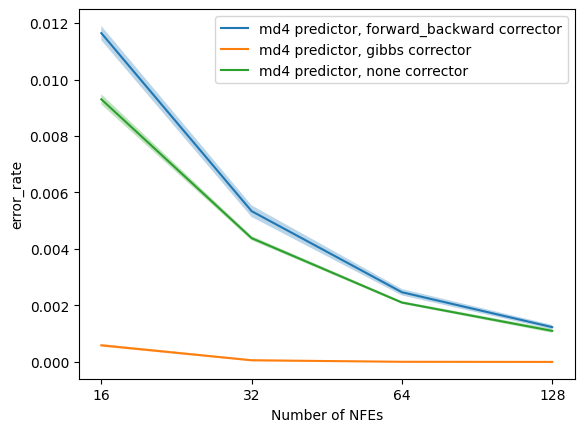

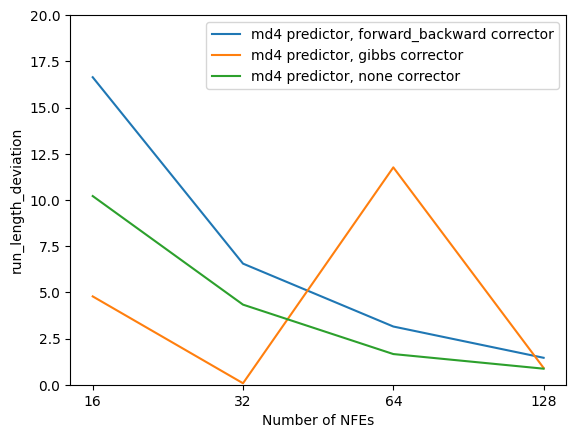

,nfe,predictor_type,corrector_type,forward_process,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,corrector_step_size,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std,run_length_deviation,weighted_score
0,16,md4,forward_backward,CosineSchedule,8,none,none,False,none,1.0,0.011643,0.000255,5.920830,0.004222,16.639627,0.178039
1,16,md4,gibbs,CosineSchedule,8,1.0,0.01,False,none,none,0.000587,0.000049,7.813837,0.118018,4.779310,0.048381
2,16,md4,none,CosineSchedule,16,none,none,False,none,none,0.009299,0.000183,6.804770,0.054035,10.209494,0.111394
3,32,md4,forward_backward,CosineSchedule,16,none,none,False,none,0.5,0.005339,0.000206,7.440200,0.083640,6.552575,0.070864
4,32,md4,gibbs,CosineSchedule,16,1.0,2.0,False,none,none,0.000058,0.000033,9.718823,0.136319,0.079061,0.000849
5,32,md4,none,CosineSchedule,32,none,none,False,none,none,0.004383,0.000075,7.918260,0.089002,4.333642,0.047719
6,64,md4,forward_backward,CosineSchedule,32,none,none,False,none,1.0,0.002468,0.000113,8.225284,0.082988,3.149615,0.033964
7,64,md4,gibbs,CosineSchedule,32,1.0,0.5,False,none,none,0.000005,0.000004,13.429510,0.114115,11.761536,0.117620
8,64,md4,none,CosineSchedule,64,none,none,False,none,none,0.002102,0.000048,8.711863,0.033035,1.659296,0.018695
9,128,md4,forward_backward,CosineSchedule,64,none,none,False,none,1.0,0.001231,0.000079,8.792914,0.084763,1.457056,0.015802


In [45]:
# Filter by corrector and nfe
df = df_full
df["run_length_deviation"] = (df["avg_run_length_mean"] - 10) ** 2
df["weighted_score"] = df["run_length_deviation"] / 100 + df["error_rate_mean"]

forward_process = "CosineSchedule"
# forward_process = "LinearSchedule"
metric = "error_rate_mean"
# metric = "run_length_deviation"
# metric = "weighted_score"

anneal_temperature = True

df = df[(df['forward_process'] == forward_process)
        & (df['corrector_type'] != 'gibbs_argmax')
        & (df['predictor_type'] != 'maskgit')
        # & (df['anneal_temperature'] == anneal_temperature)
]

best = plot_metric(df, metric)
display(best)

In [46]:
# save the best configuration
best.to_csv(f"synthetic_best_1_30_corrected.csv", index=False)

In [64]:
df_full = pd.read_csv("../results/synthetic_best_1_30_corrected.csv")

In [65]:
palette = sns.color_palette("hls", n_colors=10)
palette

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.6832, 0.33999999999999997),
 (0.7247999999999999, 0.86, 0.33999999999999997),
 (0.41279999999999994, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.5792000000000002),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.5167999999999995, 0.86),
 (0.4752000000000003, 0.33999999999999997, 0.86),
 (0.7871999999999999, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.6207999999999999)]

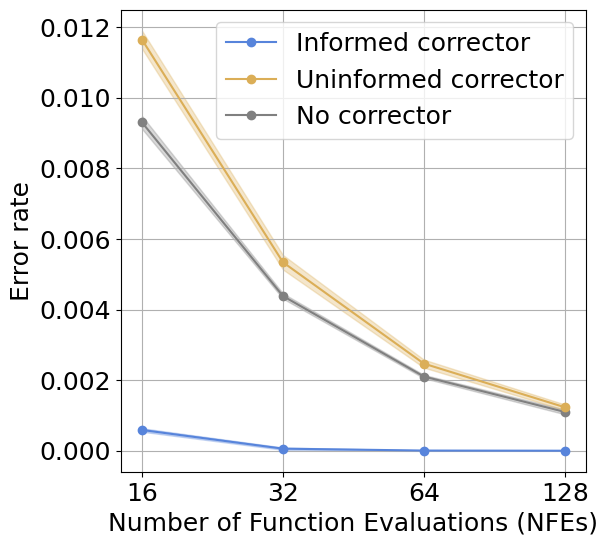

In [66]:
df = df_full
# df["NFE"] = df["num_pstep"] + (df["num_cstep"] * df["num_pstep"]) + 1
# df = df[df["NFE"] >= 16]

# The parameters are kind of confusing here
method_mapping = {
    ("md4", "none"): "No corrector",
    ("md4", "gibbs"): "Informed corrector",
    ("md4", "forward_backward"): "Uninformed corrector",
    ("maskgit", "none"): "MaskGIT (no corrector)",
}

color_mapping = {
    ("md4", "none"): 'grey',
    ("md4", "gibbs"): palette[6],
    ("md4", "forward_backward"): palette[1],
    ("maskgit", "none"): palette[0],
}


# Apply mapping function to correctly label methods
def get_corrected_method_label(row):
    key = (row["predictor_type"], row["corrector_type"])
    return method_mapping.get(key, "Other")

df["method_label"] = df.apply(get_corrected_method_label, axis=1)

# Filter only relevant methods
corrected_filtered_df = df[df["method_label"] != "Other"]

# Plot with all four groups
fig = plt.figure(figsize=(6, 6))
for label, group in corrected_filtered_df.groupby("method_label"):
    group = group.sort_values("nfe")
    plt.plot(group["nfe"], group["error_rate_mean"], marker="o", linestyle="-", 
             label=label,
             color=color_mapping.get(tuple(group[["predictor_type", "corrector_type"]].iloc[0])))
    # Plot the std as well
    plt.fill_between(group["nfe"], group["error_rate_mean"] - group["error_rate_std"],
                        group["error_rate_mean"] + group["error_rate_std"], alpha=0.3,
                        color=color_mapping.get(tuple(group[["predictor_type", "corrector_type"]].iloc[0])))

plt.xlabel("Number of Function Evaluations (NFEs)",fontsize=18)
plt.ylabel("Error rate",fontsize=18)
# plt.title("Comparison of Diffusion Sampling Methods")
# plt.legend()

# Define the desired order of legend entries
legend_order = [
    "Informed corrector",
    "Uninformed corrector",
    "No corrector",
    "MaskGIT (no corrector)",
]

# Get the legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder them based on the defined order
ordered_handles_labels = sorted(zip(handles, labels), key=lambda x: legend_order.index(x[1]))

# Unzip handles and labels
ordered_handles, ordered_labels = zip(*ordered_handles_labels)

# Apply the ordered legend
plt.legend(ordered_handles, ordered_labels,fontsize=18)


plt.xscale("log")
plt.yticks(fontsize=18)
plt.xticks([16, 32, 64, 128],fontsize=18)
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.grid(True)
plt.show()

fig.savefig("synthetic_error_rates.pdf", bbox_inches='tight')

# ImageNet (50k samples)

In [56]:
df_full = pd.read_csv("../results/results_01_29_50k.csv")

/tmp/ipykernel_197976/3031440878.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["method_label"] = df.apply(get_corrected_method_label, axis=1)


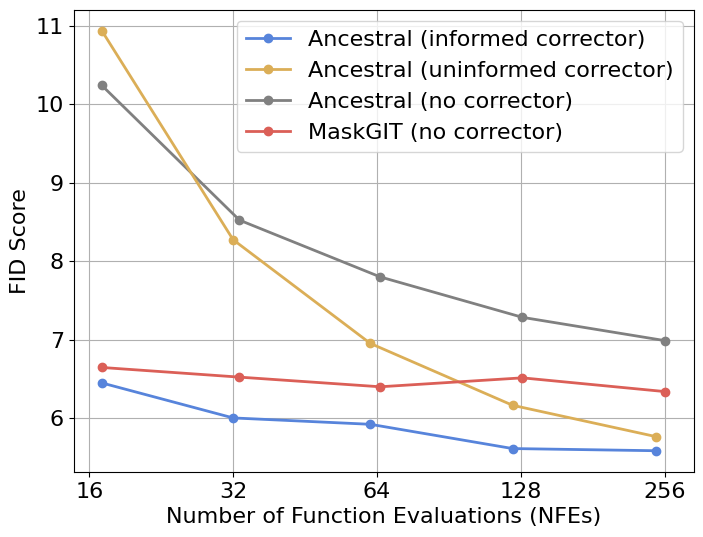

In [63]:
import math
df = df_full
df["NFE"] = df["num_pstep"] + (df["num_cstep"] * df["num_pstep"]) - (df["num_cstep"] * df["num_pstep"]) // 10 + 1
df = df[df["NFE"] >= 16]

# The parameters are kind of confusing here
method_mapping = {
    ("gibbs", 0, "gibbs"): "Ancestral (no corrector)",
    ("gibbs", 1, "gibbs"): "Ancestral (informed corrector)",
    ("euler", 1, "forward_backward"): "Ancestral (uninformed corrector)",
    ("maskgit", 0, "none"): "MaskGIT (no corrector)",
}

color_mapping = {
    ("gibbs", 0, "gibbs"): 'grey',
    ("gibbs", 1, "gibbs"): palette[6],
    ("euler", 1, "forward_backward"): palette[1],
    ("maskgit", 0, "none"): palette[0],
}


# Apply mapping function to correctly label methods
def get_corrected_method_label(row):
    key = (row["method"], row["num_cstep"], row["corrector"])
    return method_mapping.get(key, "Other")

df["method_label"] = df.apply(get_corrected_method_label, axis=1)

# Filter only relevant methods
corrected_filtered_df = df[df["method_label"] != "Other"]

# Plot with all four groups
fig = plt.figure(figsize=(8, 6))
for label, group in corrected_filtered_df.groupby("method_label"):
    group = group.sort_values("NFE")
    plt.plot(group["NFE"], group["fid"], marker="o", linestyle="-", 
             label=label, linewidth=2,
             color=color_mapping.get(tuple(group[["method", "num_cstep", "corrector"]].iloc[0])))

plt.xlabel("Number of Function Evaluations (NFEs)",fontsize=16)
plt.ylabel("FID Score",fontsize=16)
# plt.title("Comparison of Diffusion Sampling Methods")
# plt.legend()

# Define the desired order of legend entries
legend_order = [
    "Ancestral (informed corrector)",
    "Ancestral (uninformed corrector)",
    "Ancestral (no corrector)",
    "MaskGIT (no corrector)",
]

# Get the legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder them based on the defined order
ordered_handles_labels = sorted(zip(handles, labels), key=lambda x: legend_order.index(x[1]))

# Unzip handles and labels
ordered_handles, ordered_labels = zip(*ordered_handles_labels)

# Apply the ordered legend
plt.legend(ordered_handles, ordered_labels,fontsize=16)


plt.xscale("log")
plt.yticks(fontsize=16)
plt.xticks([16, 32, 64, 128, 256],fontsize=16)
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.grid(True)
plt.show()

fig.savefig("sampling_methods.pdf", bbox_inches='tight')


In [32]:
palette = sns.color_palette("hls", n_colors=10)
palette

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.6832, 0.33999999999999997),
 (0.7247999999999999, 0.86, 0.33999999999999997),
 (0.41279999999999994, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.5792000000000002),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.5167999999999995, 0.86),
 (0.4752000000000003, 0.33999999999999997, 0.86),
 (0.7871999999999999, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.6207999999999999)]

# ImageNet (old)

In [2]:
# Load the CSV file into a DataFrame
# df_old = pd.read_csv('results.csv')
# df_new = pd.read_csv('results_10_9.csv')
df_new = pd.read_csv('results_10_14.csv')

df_full = df_new

# Display the first few rows to check the data
print(df_full.head())

  method  num_cstep  entry_time  cstep_size  num_pstep corrector        fid
0  euler          1         0.9         0.5          8       NaN  17.667070
1  euler          1         0.9         0.5         16       NaN  12.744951
2  euler          1         0.9         0.5         32       NaN  11.019730
3  euler          1         0.9         0.5         64       NaN  10.241731
4  euler          1         0.9         0.5        128       NaN   9.794936


In [3]:
# df_old = df_old[
#         (df_old["corrector"] == "forward_backward") |
#         (df_old["corrector"] == "none")
#     ]
# df_full = pd.concat([df_old, df_new])

In [4]:
# Define styles
style = {
    "corrector_colors": {'forward_backward': palette[1], 'barker': palette[4], 'mpf': palette[6], 
                         'barker_full': palette[5], 'mpf_full': palette[3],
                         'none': palette[7], 'gibbs': palette[9],
                         'gibbs_uninformed': palette[8], 'gibbs_mpf': palette[2],
                         'gibbs_temp': palette[5]},
    "method_linestyles": {'tauleaping': '--', 'gillespies': '-'},
    "c_steps_linewidths": {1: 1, 2: 2},
}


In [6]:
df_full = df_full.fillna(value="none")

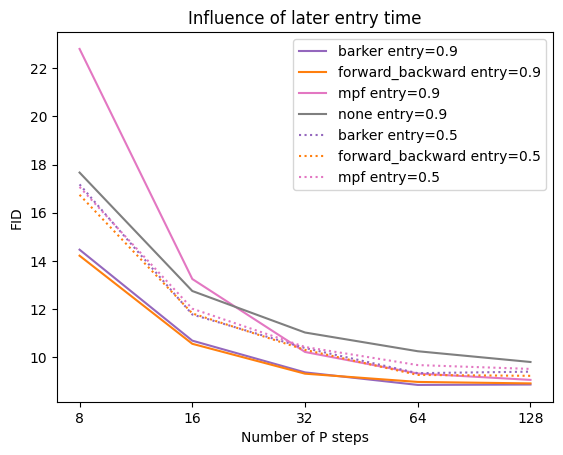

In [7]:
# Group by 'corrector' and plot
df = df_full
# Filter by corrector and step size
df = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) |
        False
]
# Filter by number of corrector steps
df_1 = df[(df['num_cstep'] == 1) & (df['entry_time'] == .9)]
# Filter by entry time

for corrector, group in df_1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} entry=0.9', 
             color=style['corrector_colors'][corrector])

# Filter by entry time
df_2 = df[(df['num_cstep'] == 1) & (df['entry_time'] == .5)]

for corrector, group in df_2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} entry=0.5', 
             color=style['corrector_colors'][corrector], linestyle=':')

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.title('Influence of later entry time')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

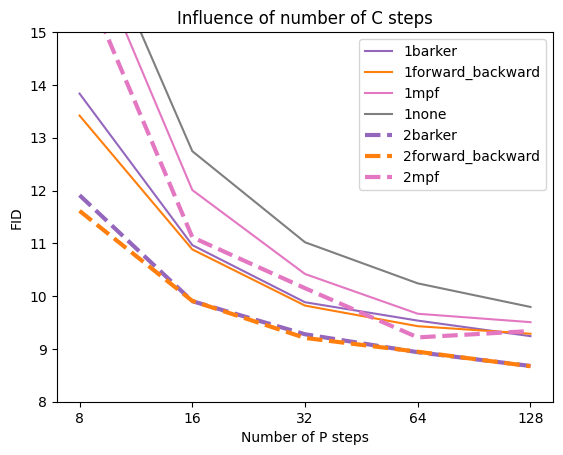

In [8]:
# Group by 'corrector' and plot
df = df_full
# Filter by corrector and step size
df = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == .5) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        False
]
# Filter by number of corrector steps
df_1 = df[(df['num_cstep'] == 1)]
# Filter by entry time

for corrector, group in df_1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'1{corrector}', 
             color=style['corrector_colors'][corrector])

# Filter by entry time
df_2 = df[(df['num_cstep'] == 2)]

for corrector, group in df_2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'2{corrector}', 
             color=style['corrector_colors'][corrector], linestyle='--', linewidth=3)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8,15))
plt.title('Influence of number of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

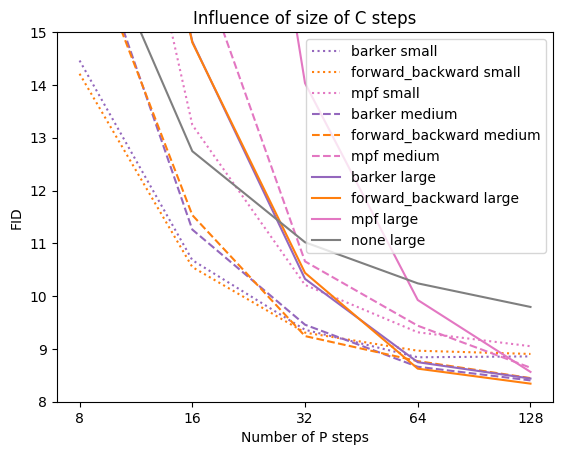

In [9]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 1)]

mpf_entry = .9

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .04) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

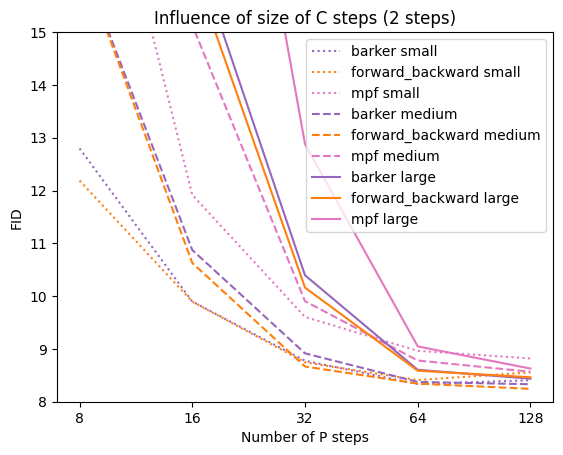

In [10]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 2)]

mpf_entry = .9

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .04) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps (2 steps)')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

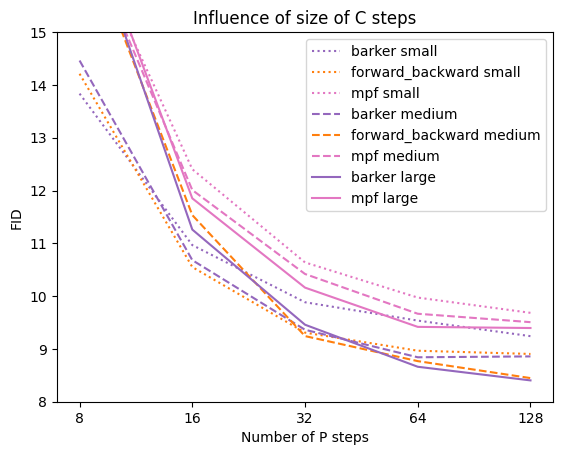

In [11]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 1)]

mpf_entry = .5

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .005) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .005) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .005) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .01) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        # (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .02) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 5.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
# plt.gca().get_xaxis().set_minor_formatter(ticker.ScalarFormatter())
plt.legend()
plt.show()

# Update: Gibbs results

In [8]:
df_gibbs = pd.read_csv('gibbs_results_11_14.csv')
# Display the first few rows to check the data
print(df_gibbs.head())

  method  num_cstep  entry_time  cstep_size  num_pstep corrector        fid  \
0  euler          1         0.9           0          8     gibbs  13.712424   
1  euler          1         0.9           0          8     gibbs  12.204210   
2  euler          1         0.9           0          8     gibbs  10.976541   
3  euler          1         0.9           0          8     gibbs  10.293639   
4  euler          1         0.9           0          8     gibbs  10.099010   

      k  
0   1.0  
1   2.0  
2   4.0  
3   8.0  
4  16.0  


In [9]:
df_gibbs_random = pd.read_csv('random_gibbs_results_11_28.csv')
df_gibbs_random["corrector"] = df_gibbs_random["corrector"].replace("gibbs","gibbs_temp")
# df_gibbs_random

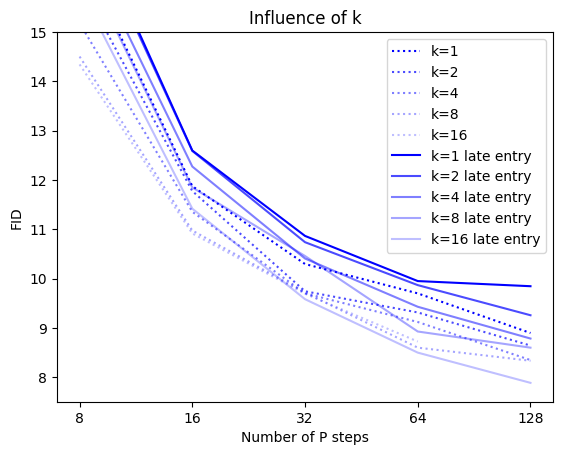

In [10]:
# Group by 'corrector' and plot
df = df_gibbs_random

corrector = 'gibbs_uninformed'
entry = .9

# Filter by corrector and step size
df1 = df[False |
         ((df['corrector'] == corrector) & (df['entry_time'] == entry))
]

for k, group in df1.groupby('k'):
    # print(group)
    plt.plot(group['num_pstep'], group['fid'], label=f'k={k}', 
             color="blue", linestyle=":", alpha=(1/k)**0.5
    )

entry = .5

# Filter by corrector and step size
df1 = df[False |
        ((df['corrector'] == corrector) & (df['entry_time'] == entry))
]

for k, group in df1.groupby('k'):
    plt.plot(group['num_pstep'], group['fid'], label=f'k={k} late entry', 
             color="blue", alpha=(1/k)**0.5
    )


plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((7.5, 15))
plt.title('Influence of k')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

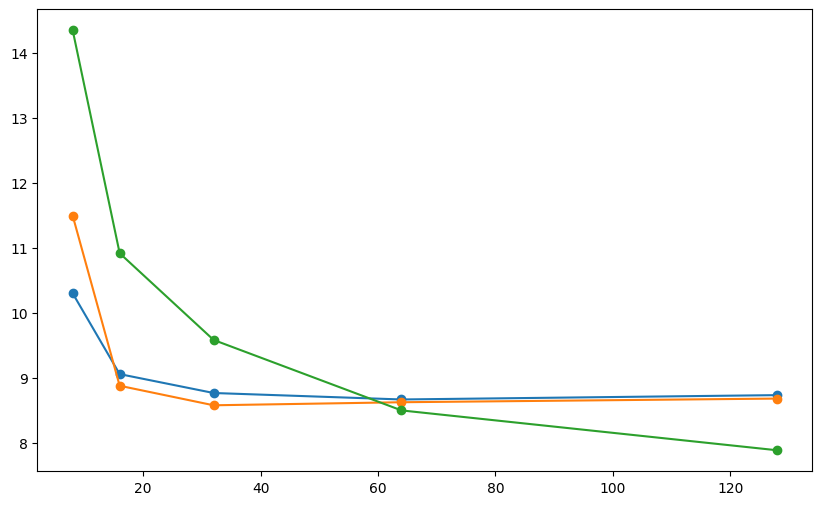

In [12]:
# Group by `corrector` and `num_pstep`, then find the minimum `fid`
best_fid = df.groupby(['corrector', 'num_pstep'])['fid'].min().reset_index()

# Create a plot for each corrector
plt.figure(figsize=(10, 6))
for corrector in best_fid['corrector'].dropna().unique():
    subset = best_fid[best_fid['corrector'] == corrector]
    plt.plot(subset['num_pstep'], subset['fid'], marker='o', label=corrector)

# Full results (Informed vs. Uninformed vs. k-Gibbs)

In [75]:
type(df)

pandas.core.frame.DataFrame

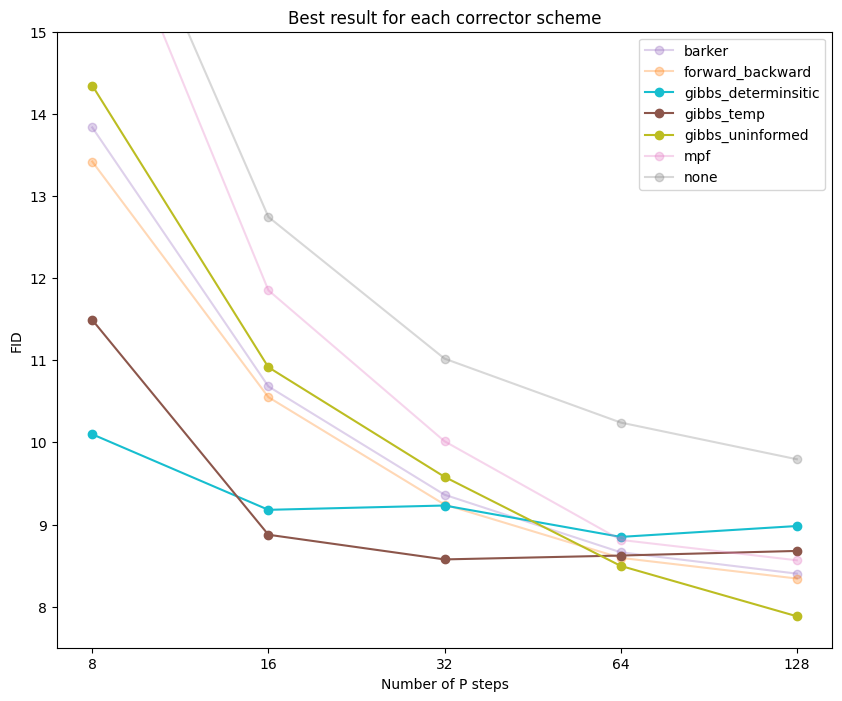

In [19]:
df = df_full
df = pd.concat([df, df_gibbs, df_gibbs_random])
df = df[(df['num_cstep'] == 1)]

best_fid = df.groupby(['corrector', 'num_pstep'])['fid'].min().reset_index()

plt.figure(figsize=(10, 8))
for corrector in best_fid['corrector'].dropna().unique():

    if corrector == "gibbs_mpf":
        continue

    label = "gibbs_determinsitic" if corrector == "gibbs" else corrector
    # alpha = 1.0
    alpha = 0.3 if "gibbs" not in corrector else 1.0
    
    subset = best_fid[best_fid['corrector'] == corrector]
    plt.plot(subset['num_pstep'], subset['fid'], marker='o', label=label, color=style['corrector_colors'][corrector],
             alpha=alpha)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((7.5, 15))
plt.title('Best result for each corrector scheme')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()